<a href="https://colab.research.google.com/github/clemuss14430/MIC-CC-ODEM-EAN/blob/main/02_commercial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FASE 2 — Análisis Comercial y VCR de Balassa (Proceso de análisis)**

## Análisis 1 — Evolución del VCR por producto (2020–2024)

In [ ]:
# Códigos del Top 10 definitivo
top10_codigos = [
    '90111', '270112', '80450', '60319', '300432',
    '611596', '730792', '30482', '200819', '60311'
]

# Filtrar solo los 10 productos en ambos datasets
can_top10 = can_limpio[
    can_limpio['cmdCode'].astype(str).str.strip().isin(top10_codigos)
].copy()

world_top10 = world_limpio[
    world_limpio['cmdCode'].astype(str).str.strip().isin(top10_codigos)
].copy()

print(f"Filas Top 10 en Canadá: {len(can_top10)}")
print(f"Filas Top 10 en Mundo: {len(world_top10)}")
print(f"\nAños disponibles: {sorted(can_top10['refYear'].unique())}")

Filas Top 10 en Canadá: 50
Filas Top 10 en Mundo: 50

Años disponibles: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
# Totales anuales (ya calculados antes, pero los recalculamos por seguridad)
total_can_anual = (can_limpio
                   .groupby('refYear')['primaryValue']
                   .sum()
                   .rename('total_CAN'))

total_world_anual = (world_limpio
                     .groupby('refYear')['primaryValue']
                     .sum()
                     .rename('total_WORLD'))

# VCR por producto y año
x_ij = (can_top10
        .groupby(['refYear', 'cmdCode', 'cmdDesc'])['primaryValue']
        .sum()
        .reset_index()
        .rename(columns={'primaryValue': 'X_CAN'}))

x_iw = (world_top10
        .groupby(['refYear', 'cmdCode'])['primaryValue']
        .sum()
        .reset_index()
        .rename(columns={'primaryValue': 'X_WORLD'}))

# Unir todo
vcr_anual = x_ij.merge(x_iw, on=['refYear', 'cmdCode'], how='left')
vcr_anual = vcr_anual.merge(total_can_anual, on='refYear', how='left')
vcr_anual = vcr_anual.merge(total_world_anual, on='refYear', how='left')

# Calcular VCR
vcr_anual['VCR'] = (
    (vcr_anual['X_CAN'] / vcr_anual['total_CAN']) /
    (vcr_anual['X_WORLD'] / vcr_anual['total_WORLD'])
).round(3)

print("VCR anual calculado:")
print(vcr_anual[['refYear','cmdCode','cmdDesc','VCR']].to_string(index=False))

VCR anual calculado:
 refYear  cmdCode                                                                                                                                                                                                                          cmdDesc    VCR
    2020    30482                                             Fish fillets; frozen, trout (Salmo trutta, Oncorhynchus mykiss, Oncorhynchus clarki, Oncorhynchus aguabonita, Oncorhynchus gilae, Oncorhynchus apache and Oncorhynchus chrysogaster) 26.480
    2020    60311                                                                                                                              Flowers, cut; roses, flowers and buds of a kind suitable for bouquets or ornamental purposes, fresh  2.092
    2020    60319                                                                   Flowers, cut; flowers and buds of a kind suitable for bouquets or ornamental purposes, fresh, other than roses, carnations, orchids, chrysanthemu

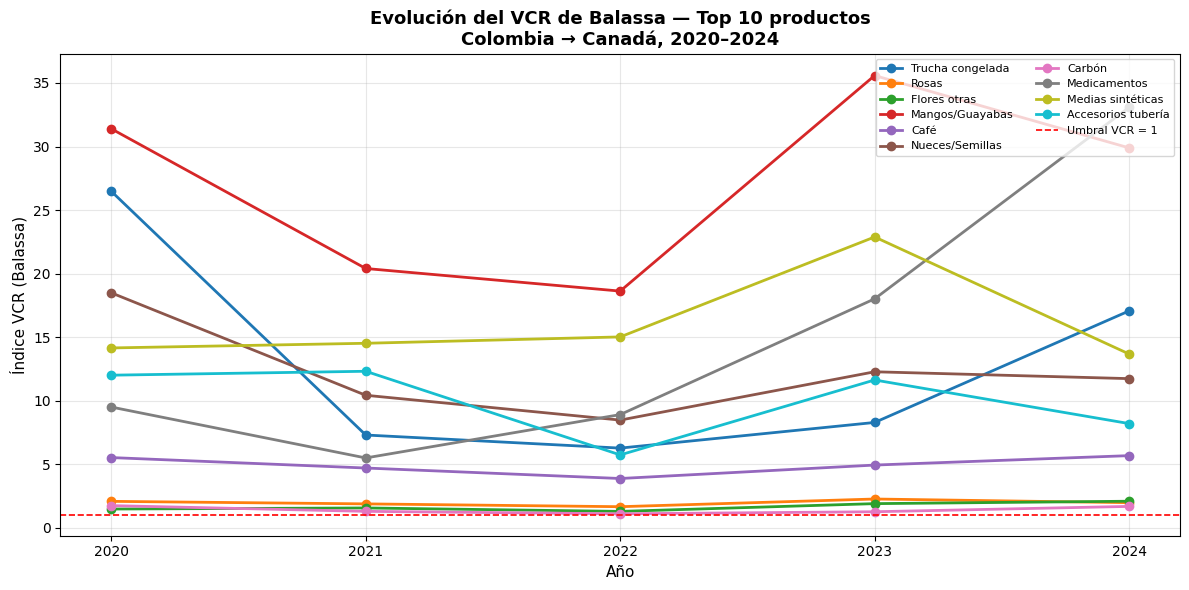

✓ Figura guardada


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Etiquetas cortas para el gráfico
etiquetas = {
    '90111':  'Café',
    '270112': 'Carbón',
    '80450':  'Mangos/Guayabas',
    '60319':  'Flores otras',
    '300432': 'Medicamentos',
    '611596': 'Medias sintéticas',
    '730792': 'Accesorios tubería',
    '30482':  'Trucha congelada',
    '200819': 'Nueces/Semillas',
    '60311':  'Rosas'
}

vcr_anual['producto'] = (vcr_anual['cmdCode']
                          .astype(str).str.strip()
                          .map(etiquetas))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

for codigo, grupo in vcr_anual.groupby('cmdCode'):
    grupo = grupo.sort_values('refYear')
    etiqueta = etiquetas.get(str(codigo).strip(), str(codigo))
    ax.plot(grupo['refYear'], grupo['VCR'],
            marker='o', linewidth=2, label=etiqueta)

# Línea VCR = 1 (umbral de ventaja comparativa)
ax.axhline(y=1, color='red', linestyle='--',
           linewidth=1.2, label='Umbral VCR = 1')

ax.set_title('Evolución del VCR de Balassa — Top 10 productos\nColombia → Canadá, 2020–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Índice VCR (Balassa)', fontsize=11)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figura_01_evolucion_vcr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada")

In [ ]:
from google.colab import files
files.download('figura_01_evolucion_vcr.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Análisis 2 — Concentración exportadora HHI

In [ ]:
# HHI por año — concentración de exportaciones Colombia → Canadá
hhi_anual = []

for year in sorted(can_limpio['refYear'].unique()):
    df_year = can_limpio[can_limpio['refYear'] == year].copy()
    total = df_year['primaryValue'].sum()
    df_year['participacion'] = df_year['primaryValue'] / total
    hhi = (df_year['participacion'] ** 2).sum()
    hhi_anual.append({'Año': year, 'HHI': round(hhi, 4)})

hhi_df = pd.DataFrame(hhi_anual)

print("Índice HHI — Concentración exportadora Colombia → Canadá:")
print(hhi_df.to_string(index=False))
print()
print("Referencia de interpretación:")
print("  HHI < 0.15  → Mercado diversificado")
print("  HHI 0.15–0.25 → Concentración moderada")
print("  HHI > 0.25  → Mercado concentrado")

Índice HHI — Concentración exportadora Colombia → Canadá:
 Año    HHI
2020 0.2358
2021 0.1947
2022 0.1802
2023 0.1537
2024 0.2033

Referencia de interpretación:
  HHI < 0.15  → Mercado diversificado
  HHI 0.15–0.25 → Concentración moderada
  HHI > 0.25  → Mercado concentrado


In [ ]:
for year in [2020, 2023]:
    df_year = can_limpio[can_limpio['refYear'] == year].copy()
    total = df_year['primaryValue'].sum()
    df_year['part_%'] = (df_year['primaryValue'] / total * 100).round(2)
    print(f"\nTop 5 productos Colombia → Canadá en {year}:")
    print(df_year.nlargest(5, 'primaryValue')[
        ['cmdCode', 'cmdDesc', 'part_%']
    ].to_string(index=False))


Top 5 productos Colombia → Canadá en 2020:
 cmdCode                                                                                                                                                        cmdDesc  part_%
   90111                                                                                                                           Coffee; not roasted or decaffeinated   43.61
  270112                                                                                              Coal; bituminous, whether or not pulverised, but not agglomerated   20.03
  270900                                                                                         Oils; petroleum oils and oils obtained from bituminous minerals, crude    4.31
   60319 Flowers, cut; flowers and buds of a kind suitable for bouquets or ornamental purposes, fresh, other than roses, carnations, orchids, chrysanthemums or lillies    3.50
   60311                                                            Flowers,

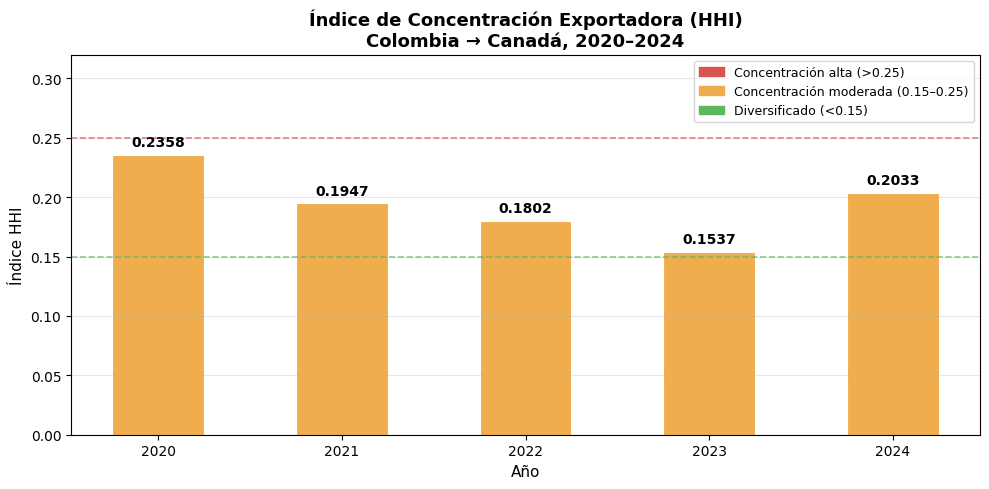

✓ Figura guardada


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))

años = hhi_df['Año']
valores = hhi_df['HHI']

# Barras con color según nivel de concentración
colores = ['#d9534f' if v > 0.25 else '#f0ad4e'
           if v > 0.15 else '#5cb85c' for v in valores]

bars = ax.bar(años, valores, color=colores,
              width=0.5, edgecolor='white', linewidth=0.8)

# Líneas de referencia
ax.axhline(y=0.25, color='#d9534f', linestyle='--',
           linewidth=1.2, alpha=0.7)
ax.axhline(y=0.15, color='#5cb85c', linestyle='--',
           linewidth=1.2, alpha=0.7)

# Etiquetas sobre cada barra
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Leyenda manual
patch_alta = mpatches.Patch(color='#d9534f',
                             label='Concentración alta (>0.25)')
patch_mod  = mpatches.Patch(color='#f0ad4e',
                             label='Concentración moderada (0.15–0.25)')
patch_div  = mpatches.Patch(color='#5cb85c',
                             label='Diversificado (<0.15)')
ax.legend(handles=[patch_alta, patch_mod, patch_div],
          fontsize=9, loc='upper right')

ax.set_title('Índice de Concentración Exportadora (HHI)\n'
             'Colombia → Canadá, 2020–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Índice HHI', fontsize=11)
ax.set_ylim(0, 0.32)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figura_02_hhi_concentracion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada")

In [ ]:
from google.colab import files
files.download('figura_02_hhi_concentracion.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Análisis 3 — Participación del Top 10 en el total exportado

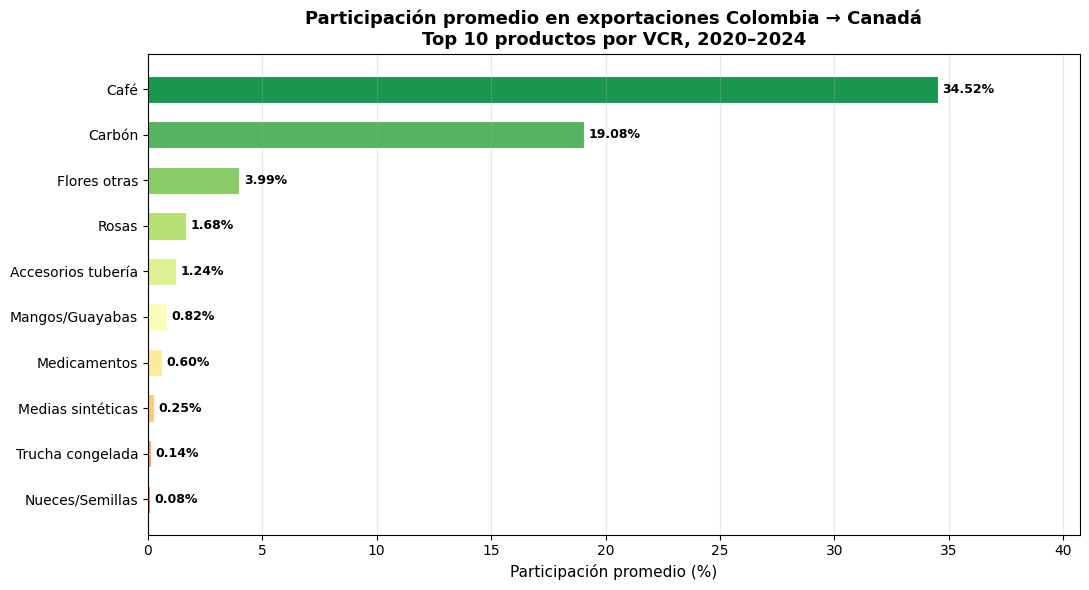

✓ Figura guardada


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Participación promedio 2020-2024 de cada producto del Top 10
participacion = []

for year in sorted(can_limpio['refYear'].unique()):
    df_year = can_limpio[can_limpio['refYear'] == year].copy()
    total = df_year['primaryValue'].sum()

    df_top = df_year[df_year['cmdCode']
                     .astype(str).str.strip()
                     .isin(top10_codigos)].copy()
    df_top['part_%'] = df_top['primaryValue'] / total * 100
    df_top['refYear'] = year
    participacion.append(df_top)

part_df = pd.concat(participacion, ignore_index=True)

# Promedio de participación por producto
part_promedio = (part_df
                 .groupby(['cmdCode', 'cmdDesc'])['part_%']
                 .mean()
                 .round(2)
                 .reset_index()
                 .sort_values('part_%', ascending=True))

# Etiquetas cortas
etiquetas = {
    '90111':  'Café',
    '270112': 'Carbón',
    '80450':  'Mangos/Guayabas',
    '60319':  'Flores otras',
    '300432': 'Medicamentos',
    '611596': 'Medias sintéticas',
    '730792': 'Accesorios tubería',
    '30482':  'Trucha congelada',
    '200819': 'Nueces/Semillas',
    '60311':  'Rosas'
}

part_promedio['nombre'] = (part_promedio['cmdCode']
                            .astype(str).str.strip()
                            .map(etiquetas))

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(11, 6))

colores = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(part_promedio))
)

bars = ax.barh(part_promedio['nombre'],
               part_promedio['part_%'],
               color=colores, edgecolor='white',
               linewidth=0.8, height=0.6)

# Etiquetas de valor
for bar, val in zip(bars, part_promedio['part_%']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center',
            fontsize=9, fontweight='bold')

ax.set_title('Participación promedio en exportaciones Colombia → Canadá\n'
             'Top 10 productos por VCR, 2020–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Participación promedio (%)', fontsize=11)
ax.set_xlim(0, max(part_promedio['part_%']) * 1.18)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figura_03_participacion_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada")

In [ ]:
from google.colab import files
files.download('figura_03_participacion_top10.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Tabla resumen integrada: VCR + participación
resumen_fase2 = part_promedio[['cmdCode', 'nombre', 'part_%']].merge(
    top10_definitivo[['cmdCode', 'VCR_promedio',
                      'años_con_ventaja',
                      'valor_promedio_anual_USD_MM']],
    on='cmdCode', how='left'
).sort_values('part_%', ascending=False).reset_index(drop=True)

resumen_fase2.index += 1
resumen_fase2.columns = [
    'cmdCode', 'Producto', 'Participación_%',
    'VCR_promedio', 'Años_con_ventaja', 'Valor_MM_USD'
]

print("RESUMEN FASE 2 — Análisis Comercial MIC-CC")
print("="*60)
print(resumen_fase2.to_string())

resumen_fase2.to_excel("tabla_02_resumen_comercial.xlsx", index=False)
files.download("tabla_02_resumen_comercial.xlsx")
print("\n✓ Tabla resumen descargada")

# HHI también
hhi_df.to_excel("tabla_03_hhi_concentracion.xlsx", index=False)
files.download("tabla_03_hhi_concentracion.xlsx")
print("✓ Tabla HHI descargada")

RESUMEN FASE 2 — Análisis Comercial MIC-CC
    cmdCode            Producto  Participación_%  VCR_promedio  Años_con_ventaja  Valor_MM_USD
1     90111                Café            34.52         4.954                 5       235.790
2    270112              Carbón            19.08         1.428                 5       137.171
3     60319        Flores otras             3.99         1.675                 5        27.596
4     60311               Rosas             1.68         1.984                 5        11.335
5    730792  Accesorios tubería             1.24         9.986                 5         8.587
6     80450     Mangos/Guayabas             0.82        27.183                 5         5.436
7    300432        Medicamentos             0.60        15.008                 5         3.960
8    611596   Medias sintéticas             0.25        16.056                 5         1.802
9     30482    Trucha congelada             0.14        13.088                 5         0.891
10   20

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Tabla resumen descargada


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Tabla HHI descargada
